# HabitIA Entrenamiento y evaluación explicados

Este cuaderno explica cómo pasamos de anuncios históricos a un modelo reproducible de **precio de oferta**, cómo medimos sus errores y cómo exportamos exactamente el modelo que utiliza el servicio. La revisión responde a dos problemas de la versión anterior: el test había participado en la selección y las variables no se preparaban igual al entrenar y al predecir.

**Qué demuestra:** rendimiento retrospectivo sobre anuncios de 2018, con agrupación por inmueble, selección interna, calibración separada e incertidumbre observada. **Qué no demuestra:** precio real de compraventa, gangas verificadas o precisión en el mercado de 2026.

Todos los resultados numéricos de las celdas siguientes se calculan o leen de los artefactos de esta ejecución. Los experimentos anteriores se conservan como evidencia exploratoria y no se reutilizan para elegir los parámetros de este protocolo.

## Cómo ejecutarlo

Abra este archivo desde la raíz de `habitia-tfm`, instale `requirements_revision.txt` en un entorno Python 3.12 y ejecute las celdas en orden. El entrenamiento completo consume CPU local; no llama a servicios de pago. La primera ejecución calcula el experimento. Si ya hay resultados completos, los carga e indica esa decisión. Para repetir todos los ajustes, cambie `REENTRENAR` a `True`; se creará una carpeta nueva y se conservará la evidencia anterior.

La validación corregida sigue siendo retrospectiva porque los datos de 2018 ya se han examinado. Una semilla nueva no convierte este histórico en una prueba externa nueva.

Antes de reutilizar resultados guardados, siga `docs/reproduccion.md`: compruebe la identidad de los datos, los hashes de código y artefacto, y las particiones. La celda de caché comprueba la configuración, pero no sustituye esa revisión. Si cambió código o datos, conserve la ejecución anterior y use una carpeta nueva.

**Nota de publicación (13/09/2026):** las salidas conservadas pertenecen a la ejecución histórica del 08/09/2026. Se han normalizado rutas del equipo y actualizado únicamente las instrucciones y referencias de distribución. Las celdas de código, tablas y gráficos conservan su contenido. El repositorio requiere el paquete privado para repetir las comprobaciones con datos; véase `docs/datos.md`.

In [1]:
from pathlib import Path
import sys, os, json, inspect, hashlib
from datetime import datetime

ROOT = next((p for p in [Path.cwd(), Path.cwd() / 'memoria', Path.cwd().parent / 'memoria']
             if (p / 'src' / 'train_revision.py').exists()), None)
assert ROOT is not None, 'Abra el notebook desde la carpeta memoria o desde TFM.'
sys.path.insert(0, str(ROOT / 'src'))
os.environ.setdefault('OMP_NUM_THREADS', '2')
import sklearn  # Antes de LightGBM para evitar el conflicto OpenMP observado en macOS.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Code
from revision_data import load_revision_data, asset_weights, ORIGINAL_COLUMNS
from model_pipeline import ModelPipeline, historical_to_payloads
from train_revision import (CONFIG, prepare_data, run_experiment, metric_values,
                            select_parameters, calibrate_groups, assert_group_separation)

pd.set_option('display.max_colwidth', 100)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
REENTRENAR = False
OUT = ROOT / 'revision_2026-09-08' / 'experimento'
if REENTRENAR:
    OUT = ROOT / 'revision_2026-09-08' / ('repeticion_' + datetime.now().strftime('%Y%m%d_%H%M%S'))
print('Python:', sys.version)
print('Resultados:', OUT)

Python: 3.12.14 (main, Aug 25 2026, 13:50:33) [Clang 22.1.3 ]
Resultados: revision_2026-09-08/experimento


## 1 La pregunta de investigación

¿Cuánto mejora un modelo que considera las características y la localización de la vivienda frente a la mediana de €/m² del barrio, cuando recibe los campos que puede proporcionar la aplicación?

La etiqueta `PRICE` es el precio anunciado. Primero estimamos un precio y su intervalo; después comparamos el anuncio con esa referencia. La segunda operación genera una **señal descriptiva**, no la predicción de una etiqueta independiente de ganga. Al entrenar no utilizamos ni `PRICE`, ni `UNITPRICE`, ni rentabilidades como variables explicativas.

## 2 Origen de los datos y qué significan

La fuente es [Idealista18](https://paezha.github.io/idealista18/), publicada por Rey-Blanco, Arbués, López y Páez (2024), con licencia [ODbL 1.0](https://paezha.github.io/idealista18/LICENSE.html). Sus precios tienen perturbación de aproximadamente ±2,5 % y redondeo; las coordenadas también fueron desplazadas. Por ello, una posición en el mapa o una diferencia pequeña de precio no debe interpretarse como una medición exacta.

El archivo local incluye enriquecimientos. Se detectaron 37 duplicaciones que coinciden en las 41 columnas originales y solo difieren en información de alquiler. Se consolidan por identidad original y se guarda qué filas se fusionaron. Las observaciones distintas de un mismo activo se conservan: no hay una fecha intratrimestral que permita elegir de forma fiable cuál sería la última.

In [2]:
data, audit = prepare_data()
display(pd.DataFrame({'variable_original': ORIGINAL_COLUMNS}))
display(Markdown('### Registro de preparación'))
print(json.dumps(audit, ensure_ascii=False, indent=2)[:16000])
print('Observaciones elegibles:', len(data))
print('Inmuebles únicos:', data.ASSETID.nunique())
display(data[['PRICE', 'CONSTRUCTEDAREA', 'ROOMNUMBER', 'BATHNUMBER']].describe())

,variable_original
0,ASSETID
1,PERIOD
2,PRICE
3,UNITPRICE
4,CONSTRUCTEDAREA
5,ROOMNUMBER
6,BATHNUMBER
7,HASTERRACE
8,HASLIFT
9,HASAIRCONDITIONING


### Registro de preparación

{
  "schema_version": "revision_data/1.0",
  "dataset": {
    "path": "data/habitia_madrid_2018.parquet",
    "sha256": "7c20dce686fb415430660167f092eb3e0ab44dae2e1221bc3db61fd94d3600ca",
    "bytes": 10969510,
    "rows_input": 94852,
    "columns_input": [
      "ASSETID",
      "PERIOD",
      "PRICE",
      "UNITPRICE",
      "CONSTRUCTEDAREA",
      "ROOMNUMBER",
      "BATHNUMBER",
      "HASTERRACE",
      "HASLIFT",
      "HASAIRCONDITIONING",
      "AMENITYID",
      "HASPARKINGSPACE",
      "ISPARKINGSPACEINCLUDEDINPRICE",
      "PARKINGSPACEPRICE",
      "HASNORTHORIENTATION",
      "HASSOUTHORIENTATION",
      "HASEASTORIENTATION",
      "HASWESTORIENTATION",
      "HASBOXROOM",
      "HASWARDROBE",
      "HASSWIMMINGPOOL",
      "HASDOORMAN",
      "HASGARDEN",
      "ISDUPLEX",
      "ISSTUDIO",
      "ISINTOPFLOOR",
      "CONSTRUCTIONYEAR",
      "FLOORCLEAN",
      "FLATLOCATIONID",
      "CADCONSTRUCTIONYEAR",
      "CADMAXBUILDINGFLOOR",
      "CADDWELLINGCOUNT",
   

,PRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER
count,9.402600e+04,94026.0,94026.0,94026.0
mean,3.950719e+05,101.246102,2.575096,1.582647
std,4.139592e+05,66.552464,1.187555,0.823015
min,2.100000e+04,21.0,0.0,0.0
25%,1.600000e+05,62.0,2.0,1.0
50%,2.630000e+05,83.0,3.0,1.0
75%,4.660000e+05,117.0,3.0,2.0
max,8.133000e+06,985.0,12.0,10.0


## 3 Limpieza y unidad de observación

Se aplican reglas fijas de validez y ámbito. No se calculan percentiles del precio sobre todo el conjunto para eliminar los extremos del test. Los valores extremos positivos que cumplen el dominio siguen participando, aunque hagan más difícil la predicción.

Cada fila es una observación; `ASSETID` agrupa observaciones del mismo inmueble. En cada partición, todas las filas de un activo permanecen juntas. Al ajustar, cada fila recibe un peso inverso al número de observaciones de su activo, normalizado para que la media del peso sea uno. Así, los activos más repetidos no dominan el ajuste.

Las métricas principales se calculan por observación para mantener una lectura comparable, y se añade una métrica por activo. Los intervalos de confianza descriptivos de las métricas remuestrean activos completos.

activos                         75225
activos_con_varias_filas        13683
maximo_filas_por_activo            11
activos_en_varios_trimestres        0
dtype: int64

Peso total mínimo/máximo por activo: 1.2499302093718843 1.2499302093718845


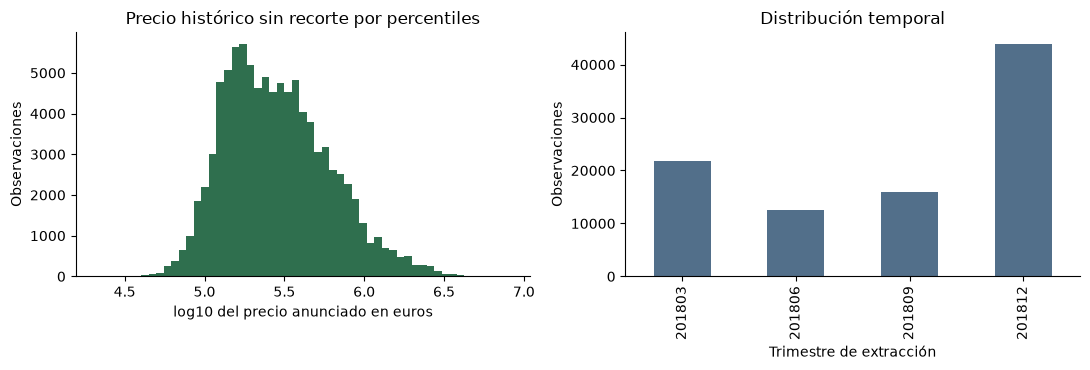

In [3]:
sizes = data.groupby('ASSETID').size()
display(pd.Series({'activos': len(sizes), 'activos_con_varias_filas': int((sizes > 1).sum()),
                   'maximo_filas_por_activo': int(sizes.max()),
                   'activos_en_varios_trimestres': int((data.groupby('ASSETID').PERIOD.nunique() > 1).sum())}))
weights = asset_weights(data)
check_weights = pd.Series(np.asarray(weights)).groupby(data.ASSETID.to_numpy()).sum()
print('Peso total mínimo/máximo por activo:', check_weights.min(), check_weights.max())
assert np.allclose(check_weights.min(), check_weights.max())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(np.log10(data.PRICE), bins=55, color='#2F6F4E')
ax[0].set(xlabel='log10 del precio anunciado en euros', ylabel='Observaciones', title='Precio histórico sin recorte por percentiles')
data.PERIOD.value_counts().sort_index().plot.bar(ax=ax[1], color='#526F8A')
ax[1].set(xlabel='Trimestre de extracción', ylabel='Observaciones', title='Distribución temporal')
plt.tight_layout(); plt.show()

## 4 Un único contrato de entrada

El entrenamiento y el servicio llaman a `ModelPipeline`. `fit` aprende medianas, categorías y centroides solo del entrenamiento. `transform` usa esas estadísticas ya fijadas sobre cualquier anuncio posterior. Las coordenadas se comparan siempre con la misma distancia geodésica en kilómetros.

El principal prescinde de Catastro y alquiler: no se ha podido acreditar su disponibilidad en 2018. Utiliza atributos observables del anuncio, variables derivadas de ellos y barrio/distrito aproximados desde los centroides de entrenamiento. Los indicadores de dato ausente distinguen un valor desconocido de un `False` observado.

El histórico no conserva `propertyType`. El adaptador utiliza estudio → dúplex → piso como prioridad técnica, documentando ese supuesto. `ISINTOPFLOOR` significa última planta y **no se transforma en ático**. La comprobación espacial de 1 km al centroide aprendido describe soporte del modelo; no es un límite municipal ni una geocodificación exacta.

In [4]:
# Ejemplo pedagógico: este fit se limita a 500 filas y NO es el modelo evaluado.
demo_rows = data.sample(500, random_state=17).reset_index(drop=True)
demo_pipeline = ModelPipeline().fit(demo_rows)
payloads = historical_to_payloads(demo_rows.head(3), include_price=True)
display(pd.DataFrame(payloads).drop(columns=['price']))
demo_x = demo_pipeline.transform(payloads, enforce_support=False)
display(demo_x.T)
forbidden = {'PRICE', 'UNITPRICE', 'rentabilidad_pct'}
assert not forbidden.intersection(demo_x.columns)
assert not any(c.startswith('CAD') or c.startswith('alq_') for c in demo_x.columns)
print('Número de variables del contrato:', len(demo_x.columns))
display(Code(inspect.getsource(ModelPipeline.transform), language='python'))

,propertyCode,size,rooms,bathrooms,floor,hasLift,exterior,latitude,longitude,municipality,propertyType,detailedType
0,A11984982571011191441,85.0,3.0,1.0,3.0,True,True,40.409915,-3.710958,Madrid,flat,"{'typology': 'flat', 'subTypology': 'flat'}"
1,A2470629292030577588,134.0,4.0,2.0,6.0,True,True,40.424706,-3.729999,Madrid,flat,"{'typology': 'flat', 'subTypology': 'flat'}"
2,A10506767700655327357,42.0,0.0,1.0,2.0,True,True,40.491783,-3.661907,Madrid,studio,"{'typology': 'flat', 'subTypology': 'studio'}"


,0,1,2
CONSTRUCTEDAREA,85.0,134.0,42.0
ROOMNUMBER,3.0,4.0,0.0
BATHNUMBER,1.0,2.0,1.0
FLOORCLEAN,3.0,6.0,2.0
HASLIFT,1.0,1.0,1.0
LATITUDE,40.409915,40.424706,40.491783
LONGITUDE,-3.710958,-3.729999,-3.661907
ISSTUDIO,0.0,0.0,1.0
ISDUPLEX,0.0,0.0,0.0
ROOMNUMBER_ausente,0.0,0.0,0.0


Número de variables del contrato: 25


def transform(self, data, *, enforce_support: bool = True) -> pd.DataFrame:
        if not self.medians:
            raise RuntimeError("Debe ejecutar fit antes de transform.")
        payloads = self._payloads(data)
        if not payloads:
            return pd.DataFrame(columns=self.columns)
        x, _ = self._raw_rows(payloads, enforce_support=enforce_support)
        for col in DIRECT_NUMERIC:
            x[col] = x[col].fillna(self.medians[col]).astype(float)
        rooms = x.ROOMNUMBER.clip(lower=1)
        x["m2_por_habitacion"] = x.CONSTRUCTEDAREA / rooms
        x["banos_por_habitacion"] = x.BATHNUMBER / rooms
        x["es_bajo"] = (x.FLOORCLEAN <= 0).astype(float)
        x["x_km"] = (x.LONGITUDE + 3.70) * 111.32 * np.cos(np.radians(40.42))
        x["y_km"] = (x.LATITUDE - 40.42) * 110.57
        x["DISTANCE_TO_CITY_CENTER"] = haversine_km(x.LATITUDE, x.LONGITUDE, *SOL)
        x["log_dist_centro"] = np.log1p(x.DISTANCE_TO_CITY_CENTER)
        for col, categories in self.categoricals.items():
            x[col] = pd.Categorical(x[col].where(x[col].isin(categories), MISSING), categories=categories)
        return x[self.columns].copy()

## 5 Selección evaluación y calibración

La evaluación exterior tiene tres folds por activo. Dentro de cada uno se reserva un 20 % de los grupos de desarrollo para calibración. El resto permite elegir parámetros con tres folds internos. Cada fold interno vuelve a aprender su propia preparación: no reutiliza medianas o centroides calculados con su validación.

Se comparan una referencia territorial, una regresión hedónica regularizada y LightGBM. La búsqueda de LightGBM considera seis configuraciones predefinidas; Ridge considera tres penalizaciones. Se elige mediante el MdAPE medio interno. No hay early stopping ni selección de variables a partir de la evaluación exterior.

Para el artefacto entregado se añade una partición histórica fija: 20 % de activos para evaluación y, del desarrollo restante, 20 % para calibración. Se conserva exactamente ese artefacto después de evaluarlo; no se reajusta silenciosamente con su test. El diagnóstico temporal ajusta y selecciona únicamente dentro de Q1–Q3 y evalúa Q4. Todas estas mediciones siguen siendo retrospectivas.

In [5]:
display(pd.DataFrame(CONFIG['lightgbm_candidates']))
print(json.dumps({k: v for k, v in CONFIG.items() if k != 'lightgbm_candidates'}, ensure_ascii=False, indent=2))
display(Code(inspect.getsource(select_parameters), language='python'))

,num_leaves,min_child_samples
0,15,30
1,15,100
2,31,30
3,31,100
4,63,30
5,63,100


{
  "version": "habitIA-oferta-2018-v2",
  "seed": 17,
  "outer_folds": 3,
  "inner_folds": 3,
  "calibration_fraction": 0.2,
  "alpha": 0.1,
  "trees": 600,
  "learning_rate": 0.05,
  "n_jobs": 2,
  "ridge_alphas": [
    1.0,
    10.0,
    100.0
  ],
  "selection_metric": "MdAPE_pct por observación; pesos iguales por activo al ajustar",
  "calibration_unit": "máximo residual conformal por ASSETID",
  "historical_data_already_explored": true,
  "support_distance_km": 1.0
}


def select_parameters(fit, config, label):
    """Selección interna; prepara de nuevo las variables dentro de cada fold."""
    rows, split_records = [], []
    folds = GroupKFold(n_splits=config["inner_folds"], shuffle=True, random_state=config["seed"])
    for k, (ia, ib) in enumerate(folds.split(fit, groups=fit.ASSETID)):
        train, valid = fit.iloc[ia].reset_index(drop=True), fit.iloc[ib].reset_index(drop=True)
        separation = assert_group_separation(train=train, valid=valid)
        pipeline = ModelPipeline(max_support_distance_km=config["support_distance_km"]).fit(train)
        valid, rejected, _ = supported_data(pipeline, valid)
        xtr = pipeline.transform(train, enforce_support=False)
        xva = pipeline.transform(valid)
        ytr = np.log(train.PRICE.to_numpy(float))
        weights = np.asarray(asset_weights(train), float)
        split_records.append({"fold": k, "particiones": separation, "abstenciones": len(rejected)})
        for j, params in enumerate(config["lightgbm_candidates"]):
            model = make_lgb(params, config).fit(xtr, ytr, sample_weight=weights)
            m = metric_values(valid.PRICE, np.exp(model.predict(xva)))
            rows.append({"fold": k, "familia": "LightGBM", "candidato": j, **m})
        rxtr, rxva = ridge_matrix(xtr), ridge_matrix(xva)
        for j, alpha in enumerate(config["ridge_alphas"]):
            model = make_ridge(rxtr, alpha).fit(rxtr, ytr, ridge__sample_weight=weights)
            m = metric_values(valid.PRICE, np.exp(model.predict(rxva)))
            rows.append({"fold": k, "familia": "Hedónico Ridge", "candidato": j, **m})
        print(f"[{label}] selección interna {k+1}/{config['inner_folds']} terminada", flush=True)
    scores = pd.DataFrame(rows).groupby(["familia", "candidato"]).MdAPE_pct.mean()
    li = int(scores.loc["LightGBM"].idxmin())
    ri = int(scores.loc["Hedónico Ridge"].idxmin())
    return {"lightgbm": config["lightgbm_candidates"][li], "ridge_alpha": config["ridge_alphas"][ri],
            "resultados_internos": rows, "particiones_internas": split_records,
            "regla": "menor media de MdAPE en folds internos; empate por orden predefinido"}

## 6 Función objetivo y precio estimado

LightGBM minimiza el error absoluto de `log(PRICE)`. La transformación logarítmica reduce la escala de diferencias entre viviendas baratas y caras; al exponenciar se obtiene una estimación aproximadamente mediana del precio condicional. No se presenta como esperanza matemática exacta ni se añade una corrección de media aprendida del test.

La referencia territorial calcula una mediana ponderada de €/m² por barrio con respaldo por distrito y global, siempre desde entrenamiento. Ridge aporta una referencia lineal regularizada con transformaciones deterministas y efectos de zona. Todos reciben las mismas observaciones aceptadas por el contrato.

## 7 Intervalos y calibración por inmueble

Se entrenan modelos cuantílicos en los niveles 0,05 y 0,95. Antes de calibrar se ordenan los bordes y se amplían para incluir el punto. Para cada observación de calibración calculamos el máximo de los dos errores laterales en escala logarítmica. Para cada activo retenemos el peor de sus registros. Un estadístico de orden con corrección por muestra finita determina `Q`, que se limita inferiormente a cero.

Este diseño evita tratar las repeticiones del mismo activo como observaciones independientes de calibración. Se informa cobertura por fila y cobertura de activos cuyos registros quedan todos dentro. La cobertura observada no garantiza un 90 % por vivienda, por barrio ni en 2026. Véase [Romano, Patterson y Candès (2019)](https://arxiv.org/abs/1905.03222).

In [6]:
display(Code(inspect.getsource(calibrate_groups), language='python'))

def calibrate_groups(ylog, point, lo, hi, groups, alpha):
    scores = np.maximum(lo-np.asarray(ylog), np.asarray(ylog)-hi)
    grouped = pd.Series(scores).groupby(np.asarray(groups)).max().to_numpy()
    rank = int(math.ceil((len(grouped)+1)*(1-alpha)))
    if rank > len(grouped):
        raise ValueError("Insuficientes activos para la calibración finita solicitada")
    q = max(0.0, float(np.sort(grouped)[rank-1]))
    return q, {"metodo": "CQR con máximo residual por activo", "unidad": "ASSETID",
               "alpha": alpha, "n_activos": len(grouped), "n_observaciones": len(scores),
               "rango_orden": rank, "Q_log": q, "incluye_punto_antes_calibrar": True,
               "garantia_individual_2026": False}

## 8 Ejecutar el experimento completo

Esta es la ejecución real: carga, selección interna, ajustes exteriores, calibración, exportación, evaluación temporal y registro de versiones. Puede tardar varios minutos. La función no consulta las métricas anteriores para tomar decisiones.

Si el fichero final ya existe, la celda verifica su configuración y muestra su fecha. Ese caso es una **lectura de una ejecución guardada**, no un entrenamiento nuevo. Las celdas posteriores vuelven a calcular tablas y comprobaciones desde las predicciones guardadas.

In [7]:
result_path = OUT / 'resultados_revision.json'
if result_path.exists():
    results = json.loads(result_path.read_text())
    print('Se leen resultados completos de:', results['created_at'])
    assert results['configuracion'] == CONFIG, 'El resultado usa otra configuración; active REENTRENAR.'
else:
    results = run_experiment(OUT)
    print('Entrenamiento ejecutado en esta sesión del notebook.')
print('Duración registrada, minutos:', round(results['duracion_segundos'] / 60, 2))
print('Hash de configuración:', results['config_sha256'])

Datos elegibles: 94026 observaciones, 75225 activos


[exterior 1] fit=50244 cal=12538 test=31244


[exterior 1] selección interna 1/3 terminada


[exterior 1] selección interna 2/3 terminada


[exterior 1] selección interna 3/3 terminada


...

[temporal] selección interna 1/3 terminada


[temporal] selección interna 2/3 terminada


[temporal] selección interna 3/3 terminada


Experimento terminado en 14.3 minutos: revision_2026-09-08/experimento


Entrenamiento ejecutado en esta sesión del notebook.
Duración registrada, minutos: 14.28
Hash de configuración: 78dde3264df14d9501cf234ce9d2102873a3307b81622767a0c326407fb45816


## 9 Interpretar el error correctamente

MdAPE es la mediana del error porcentual absoluto. Un 10 % significa que la mitad de los errores porcentuales absolutos está por debajo de ese valor, no una exactitud del 90 %. El error absoluto en euros muestra qué significa la desviación monetaria. El sesgo firmado ayuda a detectar sobreestimación o infraestimación sistemática.

La tabla exterior combina predicciones hechas fuera del entrenamiento de cada activo. No debe confundirse con la tabla del artefacto final, que corresponde a un ajuste distinto y es la que describe el modelo exportado.

In [8]:
outer = pd.read_parquet(OUT / 'predicciones_exteriores.parquet')
final = pd.read_parquet(OUT / 'predicciones_artefacto.parquet')
display(Markdown('### Evaluación exterior retrospectiva'))
display(pd.DataFrame(results['evaluacion_exterior']['metricas']).T.round(3))
display(Markdown('### Artefacto exportado evaluado en su reserva histórica'))
display(pd.DataFrame(results['artefacto_final']['metricas']).T.round(3))
print('Abstenciones exteriores:', results['evaluacion_exterior']['abstenciones'])
print('Elegibles exteriores:', results['evaluacion_exterior']['n_elegibles'])
display(pd.DataFrame(results['evaluacion_exterior']['bootstrap']))
assert outer.source_row_id.is_unique
recomputed = metric_values(outer.PRICE, outer.pred_lgb, outer.ASSETID,
                           outer.limite_inferior, outer.limite_superior)
assert np.isclose(recomputed['MdAPE_pct'], results['evaluacion_exterior']['metricas']['LightGBM']['MdAPE_pct'])

### Evaluación exterior retrospectiva

,n,MdAPE_pct,MAPE_pct,MAE_eur,MdAE_eur,sesgo_mediano_pct,dentro_10_pct,dentro_20_pct,n_activos,mediana_APE_mediano_por_activo_pct,cobertura_pct,anchura_mediana_eur,anchura_relativa_mediana_pct,puntos_fuera_intervalo,intervalos_invertidos,cobertura_activos_todos_registros_pct
Referencia territorial,93944.0,15.412,20.442,75878.941,40357.143,-0.492,34.022,61.426,75162.0,15.496,NaN,NaN,NaN,NaN,NaN,NaN
Hedónico Ridge,93944.0,13.127,17.433,67362.731,33716.317,-0.967,39.432,68.775,75162.0,13.193,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,93944.0,10.312,14.767,55440.320,26854.845,-0.525,48.818,76.619,75162.0,10.298,90.77,163609.873,62.328,0.0,0.0,89.915


### Artefacto exportado evaluado en su reserva histórica

,n,MdAPE_pct,MAPE_pct,MAE_eur,MdAE_eur,sesgo_mediano_pct,dentro_10_pct,dentro_20_pct,n_activos,mediana_APE_mediano_por_activo_pct,cobertura_pct,anchura_mediana_eur,anchura_relativa_mediana_pct,puntos_fuera_intervalo,intervalos_invertidos,cobertura_activos_todos_registros_pct
Referencia territorial,18782.0,15.552,20.395,75936.143,40106.701,-0.671,33.915,61.085,15031.0,15.513,NaN,NaN,NaN,NaN,NaN,NaN
Hedónico Ridge,18782.0,13.044,17.250,66574.484,33003.590,-0.976,39.655,68.635,15031.0,13.009,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,18782.0,10.251,14.549,54884.076,26439.221,-0.557,49.100,76.898,15031.0,10.161,90.933,159105.575,61.482,0.0,0.0,90.214


Abstenciones exteriores: 82
Elegibles exteriores: 94026


,unidad,repeticiones,tipo,alcance,MdAPE_pct,mejora_frente_baseline_pp,cobertura_pct
0,ASSETID,400,percentil 95 % descriptivo,variación de observaciones evaluadas; no incluye toda la incertidumbre del ajuste,10.210312,4.960595,90.556362
1,ASSETID,400,percentil 95 % descriptivo,variación de observaciones evaluadas; no incluye toda la incertidumbre del ajuste,10.424718,5.250771,90.992115


## 10 Comparación visual y diagnóstico de residuos

Los gráficos permiten ver si la mejora agregada oculta zonas de precio con errores grandes. La diagonal representa coincidencia entre precio anunciado y estimado; no una validación del valor de compraventa. El gráfico de residuos usa el signo: positivo indica sobreestimación.

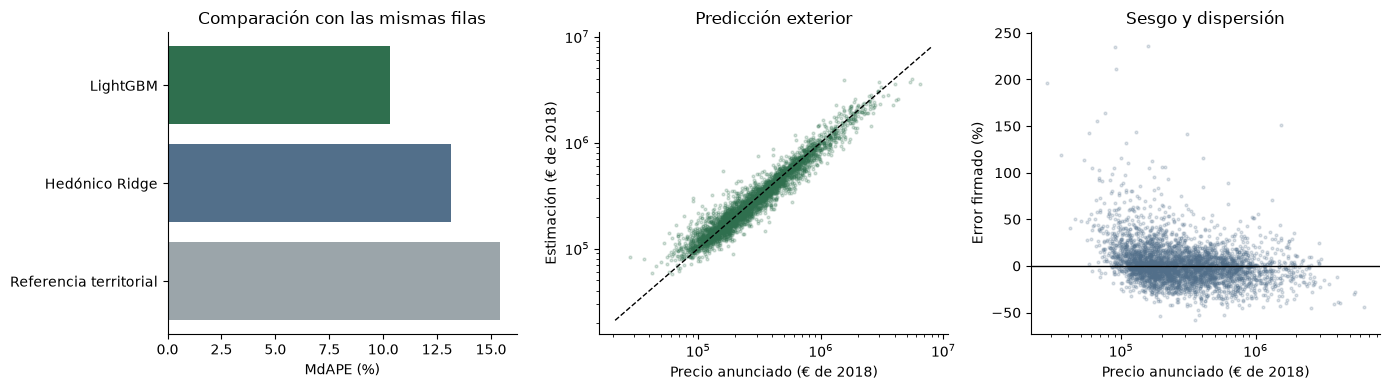

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
table = pd.DataFrame(results['evaluacion_exterior']['metricas']).T
axes[0].barh(table.index, table.MdAPE_pct, color=['#9BA5AA', '#526F8A', '#2F6F4E'])
axes[0].set(xlabel='MdAPE (%)', title='Comparación con las mismas filas')
s = outer.sample(min(4000, len(outer)), random_state=17)
axes[1].scatter(s.PRICE, s.pred_lgb, s=4, alpha=.2, color='#2F6F4E')
limits = [outer.PRICE.min(), outer.PRICE.max()]
axes[1].plot(limits, limits, '--', color='black', linewidth=1)
axes[1].set(xscale='log', yscale='log', xlabel='Precio anunciado (€ de 2018)', ylabel='Estimación (€ de 2018)', title='Predicción exterior')
axes[2].scatter(s.PRICE, (s.pred_lgb-s.PRICE)/s.PRICE*100, s=4, alpha=.2, color='#526F8A')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set(xscale='log', xlabel='Precio anunciado (€ de 2018)', ylabel='Error firmado (%)', title='Sesgo y dispersión')
plt.tight_layout(); plt.show()

## 11 Errores por distrito y por tramo de precio

Se publican tamaños de muestra junto a las métricas. Los deciles son un diagnóstico calculado después de evaluar: no eliminan observaciones ni deciden parámetros. Una cobertura agregada cercana al nivel nominal puede ocultar un comportamiento distinto en viviendas baratas o caras. El remuestreo por activo de la tabla anterior estima variación descriptiva de los casos evaluados; no incluye toda la incertidumbre de volver a entrenar el sistema.

<!-- HABITIA_INTERPRETACION_JSON -->
**Lectura de la ejecución entregada.** En el decil más barato, con 9.498 anuncios de 21.000 a 118.000 € de 2018, el MdAPE es **16,24 %**, el sesgo mediano es **+14,86 %** (sobreestimación) y la cobertura por anuncio es **81,81 %**. Eso deja aproximadamente 18,19 de cada 100 anuncios de este tramo fuera de su intervalo. La cobertura global oculta aquí una limitación real: una brecha negativa en una vivienda barata necesita revisión, pues puede reflejar un error sistemático del modelo. Estos deciles usan el precio real anunciado para diagnosticar después de evaluar; no constituyen una garantía ni una regla de recalibración validada para anuncios nuevos.

*Cifras tomadas de `revision_2026-09-08/experimento/resultados_revision.json`, ejecución registrada 2026-09-08T10:56:07.779466+00:00. Si se ejecuta otro experimento, se deben renovar estas interpretaciones a partir de su JSON.*

,segmento,n,n_activos,MdAPE_pct,sesgo_mediano_pct,cobertura_pct,anchura_relativa_mediana_pct
0,Arganzuela,4363,3592,8.95,-0.57,90.88,57.34
1,Barajas,1091,875,7.34,-0.24,91.48,46.56
2,Carabanchel,6670,5216,11.77,-0.94,90.85,71.19
3,Centro,11500,9171,10.82,-0.37,90.85,63.78
4,Chamartin,5110,4061,9.93,-0.64,90.68,57.67
5,Chamberi,6253,4994,9.11,-0.19,90.64,55.24
6,Ciudad Lineal,5680,4443,11.11,-0.68,91.36,65.40
7,Fuencarral-El Pardo,3519,2760,9.19,-0.38,90.62,54.65
8,Hortaleza,3439,2728,9.81,-0.72,90.23,64.35
9,Latina,4601,3816,10.48,-0.33,91.05,64.24


,segmento,precio_min,precio_max,n,MdAPE_pct,MAPE_pct,MAE_eur,MdAE_eur,sesgo_mediano_pct,dentro_10_pct,dentro_20_pct,n_activos,mediana_APE_mediano_por_activo_pct,cobertura_pct,anchura_mediana_eur,anchura_relativa_mediana_pct,puntos_fuera_intervalo,intervalos_invertidos,cobertura_activos_todos_registros_pct
0,1,21000.0,118000.0,9498,16.24,26.39,23079.83,15724.17,14.86,33.71,57.95,8265,16.71,81.81,78413.17,83.57,0,0,80.48
1,2,119000.0,146000.0,9460,9.80,14.48,19123.32,12966.81,2.58,50.71,78.21,8098,9.91,93.88,89720.03,67.72,0,0,93.44
2,3,147000.0,175000.0,9303,9.80,14.08,22560.60,15690.85,-0.00,50.87,79.76,7963,9.69,93.34,104545.83,65.20,0,0,92.97
3,4,176000.0,214000.0,9473,10.28,13.91,26887.83,19822.42,-0.68,48.89,77.60,7981,10.24,93.17,122898.45,63.72,0,0,92.65
4,5,215000.0,263000.0,9365,10.48,13.75,32713.56,24937.58,-2.74,48.12,77.11,7851,10.47,92.76,145227.99,60.77,0,0,92.24
5,6,264000.0,329000.0,9325,9.92,13.11,38522.80,29201.03,-1.55,50.24,78.93,7806,9.84,91.53,175237.95,59.52,0,0,91.02
6,7,330000.0,410000.0,9376,8.99,12.22,44974.48,33179.25,-2.04,54.18,81.16,7825,8.86,91.04,211111.03,57.45,0,0,90.57
7,8,411000.0,547000.0,9375,8.88,12.03,56707.25,41701.63,-1.90,54.60,82.40,7602,8.85,91.80,266661.80,56.92,0,0,90.98
8,9,548000.0,797000.0,9380,9.59,12.71,83469.79,62391.84,-2.98,51.70,79.77,7498,9.55,91.00,364481.58,55.78,0,0,90.18
9,10,798000.0,8133000.0,9389,11.33,14.83,206809.20,133815.17,-5.43,45.38,73.56,7308,11.47,87.47,659604.31,57.71,0,0,86.47


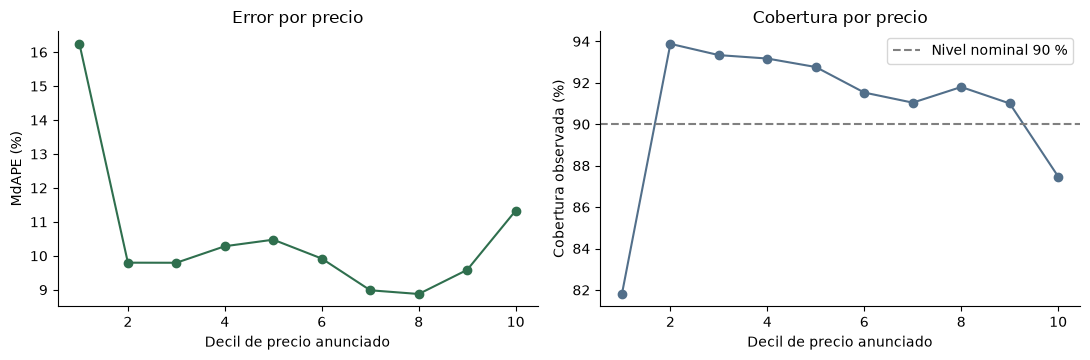

In [10]:
segments = results['evaluacion_exterior']['segmentos']
display(pd.DataFrame(segments['distrito'])[['segmento','n','n_activos','MdAPE_pct','sesgo_mediano_pct','cobertura_pct','anchura_relativa_mediana_pct']].round(2))
deciles = pd.DataFrame(segments['decil_precio'])
display(deciles.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
axes[0].plot(deciles.segmento, deciles.MdAPE_pct, 'o-', color='#2F6F4E')
axes[0].set(xlabel='Decil de precio anunciado', ylabel='MdAPE (%)', title='Error por precio')
axes[1].plot(deciles.segmento, deciles.cobertura_pct, 'o-', color='#526F8A')
axes[1].axhline(90, color='gray', linestyle='--', label='Nivel nominal 90 %')
axes[1].set(xlabel='Decil de precio anunciado', ylabel='Cobertura observada (%)', title='Cobertura por precio')
axes[1].legend(); plt.tight_layout(); plt.show()

## 12 Diagnóstico temporal

Los parámetros del diagnóstico temporal se seleccionan únicamente con Q1–Q3. Q4 nunca se utiliza en ese ajuste o calibración. Aun así, el análisis sigue siendo retrospectivo porque el proyecto ya había inspeccionado Q4 antes de esta revisión. La diferencia entre resultados agrupados y temporales ayuda a discutir estabilidad; no valida por sí sola el salto hasta 2026.

<!-- HABITIA_INTERPRETACION_JSON -->
**Lectura de la ejecución entregada.** En los 43.839 anuncios aceptados de Q4, el MdAPE es **11,22 %**, frente al 10,31 % de la evaluación exterior agrupada. El sesgo mediano de **-4,24 %** indica infraestimación: la estimación tiende a quedar por debajo del precio anunciado. La cobertura es **89,35 % por observación** y **87,88 % por activo con todos sus registros cubiertos**; la unidad de medida importa. El modelo cambia de comportamiento al evaluarse en otro período, pero esta diferencia no se puede atribuir solo al calendario: también cambian el tamaño de ajuste y la composición de la muestra. No ofrece evidencia de precisión en 2026.

*Cifras tomadas de `revision_2026-09-08/experimento/resultados_revision.json`, ejecución registrada 2026-09-08T10:56:07.779466+00:00. Si se ejecuta otro experimento, se deben renovar estas interpretaciones a partir de su JSON.*

In [11]:
if results['temporal'] is not None:
    display(pd.DataFrame(results['temporal']['metricas']).T.round(3))
    print('Abstenciones temporales:', results['temporal']['abstenciones_evaluacion'])
    display(results['temporal']['particiones'])

,n,MdAPE_pct,MAPE_pct,MAE_eur,MdAE_eur,sesgo_mediano_pct,dentro_10_pct,dentro_20_pct,n_activos,mediana_APE_mediano_por_activo_pct,cobertura_pct,anchura_mediana_eur,anchura_relativa_mediana_pct,puntos_fuera_intervalo,intervalos_invertidos,cobertura_activos_todos_registros_pct
Referencia territorial,43839.0,15.114,19.266,76872.232,41000.000,-5.146,34.314,62.554,31139.0,15.160,NaN,NaN,NaN,NaN,NaN,NaN
Hedónico Ridge,43839.0,12.995,16.504,68491.427,34334.803,-4.859,39.499,69.842,31139.0,13.055,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,43839.0,11.216,14.778,60302.829,29848.876,-4.238,45.462,75.079,31139.0,11.274,89.35,165360.672,60.397,0.0,0.0,87.88


Abstenciones temporales: 60


{'fit': {'filas': 40144, 'activos': 35231},
 'calibracion': {'filas': 9983, 'activos': 8808},
 'evaluacion': {'filas': 43899, 'activos': 31186}}

## 13 Interpretabilidad del modelo evaluado

Se calculan contribuciones SHAP con LightGBM sobre una muestra fijada de observaciones exteriores. La magnitud media absoluta indica cuánto suele contribuir cada variable a la salida del modelo en log euros. No significa cuánto aumentaría causalmente el precio si reformáramos una vivienda. Variables correlacionadas pueden repartirse la atribución de maneras distintas.

,SHAP absoluto medio en log euros
CONSTRUCTEDAREA,0.302430
distrito,0.173636
barrio,0.157847
BATHNUMBER,0.104074
HASLIFT,0.067000
FLOORCLEAN,0.033954
DISTANCE_TO_CITY_CENTER,0.025628
m2_por_habitacion,0.018818
FLATLOCATIONID_cat,0.012459
LATITUDE,0.010503


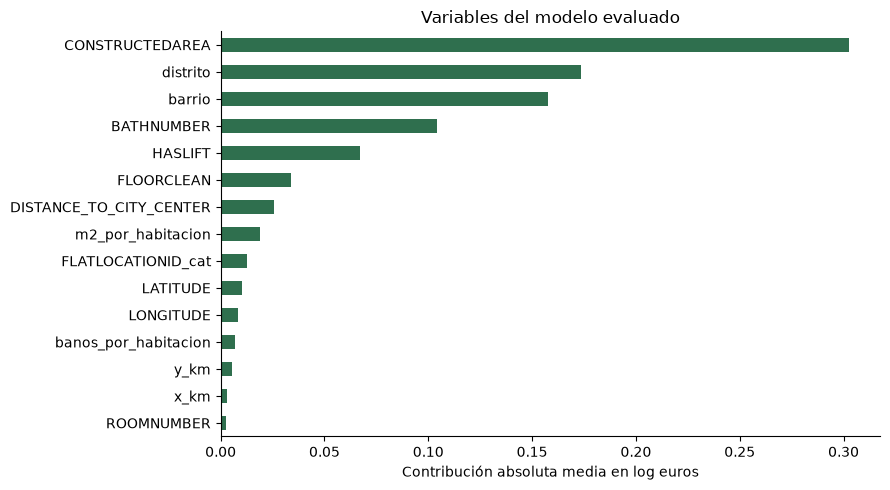

In [12]:
shap_parts = [pd.Series(fold['shap']['media_absoluta']) for fold in results['evaluacion_exterior']['folds']]
shap_mean = pd.concat(shap_parts, axis=1).mean(axis=1).sort_values()
display(shap_mean.sort_values(ascending=False).to_frame('SHAP absoluto medio en log euros'))
fig, ax = plt.subplots(figsize=(9, 5))
shap_mean.tail(15).plot.barh(ax=ax, color='#2F6F4E')
ax.set(xlabel='Contribución absoluta media en log euros', title='Variables del modelo evaluado')
plt.tight_layout(); plt.show()

## 14 Comprobar el artefacto servido

La prueba siguiente carga los archivos exportados a través de `Valorador`, reconstruye anuncios y contrasta sus respuestas con las predicciones registradas. Cambia después únicamente el precio anunciado: la estimación debe permanecer idéntica, aunque la brecha cambie. No se llama a Fly ni a Idealista.

También se comprueba que el artefacto y sus metadatos tienen los hashes declarados. Una carpeta que mezcla modelos y preparación de ejecuciones distintas no es un despliegue válido.

In [13]:
from valorador import Valorador
artifact = OUT / 'artefacto'
manifest = json.loads((artifact / 'manifiesto.json').read_text())
for name, expected in manifest['sha256'].items():
    assert hashlib.sha256((artifact / name).read_bytes()).hexdigest() == expected
v = Valorador(artifact)
chosen = final.head(20)
rows = data.set_index('source_row_id').loc[chosen.source_row_id].reset_index()
ads = historical_to_payloads(rows, include_price=True)
responses = v.valorar(ads, renivelar=False)
served = np.asarray([r['precio_estimado'] for r in responses])
assert np.max(np.abs(served - chosen.pred_lgb.to_numpy())) <= 0.500001
assert all(r['intervalo'][0] <= r['precio_estimado'] <= r['intervalo'][1] for r in responses)
changed = {**ads[0], 'price': ads[0]['price'] * 1.5}
assert v.valorar(changed)['precio_estimado'] == responses[0]['precio_estimado']
display(pd.DataFrame(responses)[['precio_anunciado','precio_estimado','intervalo','brecha_pct','barrio','nivel_precios']])
print('Paridad con el servicio verificada en', len(responses), 'casos; diferencia máxima permitida: redondeo a euros.')

,precio_anunciado,precio_estimado,intervalo,brecha_pct,barrio,nivel_precios
0,3187000,2104963,"[1046049, 2686609]",51.4,Palacio,2018
1,213000,209563,"[144445, 259945]",1.6,Palacio,2018
2,211000,195689,"[144715, 252836]",7.8,Palacio,2018
3,1013000,866288,"[629899, 1071819]",16.9,Palacio,2018
4,254000,272694,"[190673, 334761]",-6.9,Palacio,2018
5,236000,247998,"[179727, 308766]",-4.8,Palacio,2018
6,960000,721376,"[473668, 991226]",33.1,Palacio,2018
7,430000,539807,"[352900, 657074]",-20.3,Palacio,2018
8,800000,906854,"[540723, 1320035]",-11.8,Palacio,2018
9,499000,536774,"[378477, 675542]",-7.0,Embajadores,2018


Paridad con el servicio verificada en 20 casos; diferencia máxima permitida: redondeo a euros.


## 15 Cómo leer una señal de precio

Un anuncio situado por debajo del borde inferior merece revisión frente al modelo, pero puede tener información omitida, defectos o condiciones que expliquen su precio. La etiqueta no se ha validado frente a operaciones cerradas ni a valoraciones independientes de especialistas. Una rentabilidad definida como alquiler dividido por el mismo precio de venta no sirve como prueba independiente de ganga.

El servicio diferencia el nivel histórico de 2018 del escenario indexado mediante el factor heredado del IPV. Aplicar un índice agregado no verifica el comportamiento de cada barrio o inmueble. Las respuestas indexadas deben mostrar ese carácter exploratorio.

In [14]:
historical = v.valorar(ads[0], renivelar=False)
scenario = v.valorar(ads[0], renivelar=True)
display(pd.DataFrame([{'escenario': '2018', 'estimacion': historical['precio_estimado'],
                       'intervalo': historical['intervalo']},
                      {'escenario': scenario['nivel_precios'] + ' indexado',
                       'estimacion': scenario['precio_estimado'], 'intervalo': scenario['intervalo']}]))
print('Factor de escenario:', manifest['renivelado']['factor'])
print('Precisión actual validada:', scenario['precision_actual_validada'])
try:
    v.valorar({**ads[0], 'municipality': 'Barcelona'})
except ValueError as e:
    print('Abstención esperada:', e)

,escenario,estimacion,intervalo
0,2018,2104963,"[1046049, 2686609]"
1,2026T1 indexado,3269849,"[1624933, 4173378]"


Factor de escenario: 1.5534
Precisión actual validada: False
Abstención esperada: Solo se admiten anuncios que indiquen municipality='Madrid' (capital).


## 16 Conclusiones y límites que deben aparecer en la defensa

La conclusión se obtiene comparando la tabla real con la referencia territorial, revisando sesgo, cobertura, anchura y abstenciones. Una mejora del promedio no elimina los fallos en segmentos concretos. El modelo exportado recibe la misma preparación que el evaluado y conserva por separado sus grupos de calibración y evaluación.

Persisten límites sustantivos: datos históricos ya explorados, precios de oferta perturbados, coordenadas aproximadas, tipo bruto de inmueble ausente, falta de muestra contemporánea y ausencia de etiquetas independientes de oportunidad. Un resultado honesto puede ser menos espectacular que el de una evaluación contaminada y, aun así, aportar más evidencia.

### Archivos para reproducir y auditar

- `src/revision_data.py`: origen, consolidación, exclusiones y pesos.
- `src/model_pipeline.py`: preparación compartida.
- `src/train_revision.py`: selección, evaluación, calibración y exportación.
- `src/valorador.py` y `servicio/api.py`: inferencia y contrato HTTP.
- `revision_2026-09-08/experimento`: configuración, particiones, predicciones, métricas y artefacto.
- `docs/verificacion-entrega.md`: comprobaciones de la distribución y límites de la entrega.

### Referencias metodológicas

- [Rey-Blanco et al. (2024), datos de Idealista](https://journals.sagepub.com/doi/10.1177/23998083241242844).
- [scikit-learn, preparación y prevención de fugas](https://scikit-learn.org/stable/common_pitfalls.html).
- [scikit-learn, evaluación con grupos](https://scikit-learn.org/stable/modules/cross_validation.html).
- [Romano, Patterson y Candès (2019), Conformalized Quantile Regression](https://arxiv.org/abs/1905.03222).
- [Lundberg y Lee (2017), A Unified Approach to Interpreting Model Predictions](https://arxiv.org/abs/1705.07874).
- [LightGBM, Booster.predict y contribuciones nativas pred_contrib](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.Booster.html).